# Bluesky Data Science
## Part 06 - Natural Language Processing of Post Content

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

*An [R Markdown counterpart](../../RMarkdown/Part%2006%20-%20Natural%20Language%20Processing/Part%2006%20-%20Natural%20Language%20Processing.Rmd) of this notebook, using the [bskyr](https://christophertkenny.com/bskyr/) package, lives in the parallel `RMarkdown/` directory.*


## Background

> **tl;dr**: This notebook turns the *text* of Bluesky posts into quantitative measures: word and phrase frequencies, sentiment scores, and topics. Along the way it covers the preprocessing decisions that short social media text demands and the validation habits that keep automated text analysis honest.

The previous notebooks treated posts mostly as *events* — things that happen at a time, get engagement, and connect accounts. But the posts themselves are language, and for social scientists language is data. What are people talking about? How do they feel about it? Do different communities talk about the same events in different words? These questions launched an entire subfield when Twitter data became available: O'Connor *et al.* (2010) famously showed that simple sentiment counts over tweets tracked consumer-confidence and presidential-approval polls, and a decade of "text as data" methods followed.

There are three broad families of automated content analysis, and this notebook touches the first two:

1. **Dictionary methods** count words from a curated lexicon. They are transparent and fast but inherit every blind spot of their dictionary. Our example is **VADER** (Hutto & Gilbert 2014), a sentiment lexicon built specifically for social media text.
2. **Unsupervised methods** discover structure without labels. Our example is **Latent Dirichlet Allocation (LDA)** topic modeling, which describes each document as a mixture of word-distribution "topics."
3. **Supervised methods** learn from human-labeled examples. We defer these to Part 08, where a large language model plays the role of the annotator and we validate it against human judgment.

Whatever the method, the governing principle comes from [Grimmer & Stewart (2013)](https://doi.org/10.1093/pan/mps028): all quantitative models of language are wrong — but some are useful — so **validate, validate, validate**. We will keep coming back to that.

If you want more depth than one notebook can offer, two accessible companions to keep open are that Grimmer & Stewart review article and its book-length successor, [*Text as Data: A New Framework for Machine Learning and the Social Sciences*](https://press.princeton.edu/books/paperback/9780691207551/text-as-data) (Grimmer, Roberts, & Stewart 2022). For the craft of traditional (human-coded) content analysis that all of these methods are trying to automate, Krippendorff's [*Content Analysis*](https://doi.org/10.4135/9781071878781) is the standard reference.

### Learning objectives

After working through this notebook you will be able to:

1. Build a text corpus from author feeds when authenticated search is unavailable, reusing the facet-based snowball logic from Part 02
2. Filter posts by language using the `langs` field on post records
3. Preprocess short social text — URLs, @-handles, hashtags, contractions — with a transparent, inspectable pipeline
4. Compute word and n-gram frequencies with scikit-learn's `CountVectorizer` and find each account's *distinctive* vocabulary with log-odds ratios
5. Score sentiment with VADER, visualize its distribution and monthly trend, and articulate its failure modes
6. Fit and interpret an LDA topic model: top words per topic, document-topic mixtures, and topic prevalence by account
7. Explain when to reach for transformer sentence embeddings instead of word counts
8. Hand-validate automated measures and connect them to the LLM-annotation workflow in Part 08

## Setup

The usual scientific Python stack, plus two part-specific imports: `vaderSentiment` for dictionary-based sentiment, and a small helper module `textprep.py` (in this notebook's directory) that holds our text-cleaning functions so we can reuse and test them outside the notebook.

In [1]:
# Handling time, dates, and patience between API calls
import time
from datetime import datetime, timezone

# Counting things
from collections import Counter

# Regular expressions for inspecting text
import re

# DataFrames and arrays
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

# Show more of each post when displaying DataFrames
pd.set_option('display.max_colwidth', 100)

Three of these imports deserve a word. [`vaderSentiment`](https://github.com/cjhutto/vaderSentiment) ships the VADER lexicon and scorer we use for sentiment in Section 4. From [scikit-learn](https://scikit-learn.org/stable/), the standard Python machine-learning library, we take [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), which turns a column of texts into a matrix of word counts (Section 3), and [`LatentDirichletAllocation`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html), the topic model of Section 5. The helper module `textprep.py` sits in this notebook's directory — open it and read it; it is short on purpose, because every line of a preprocessing pipeline is a measurement decision you should be able to defend.

In [2]:
# Part-specific helpers: cleaning, tokenizing, log-odds, topic tables
import textprep

# Sentiment lexicon built for social media (Hutto & Gilbert 2014)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Document-term matrices and topic models
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

Connect to Bluesky with the shared `bsky_client` helper. With an `atproto.json` credentials file you get an authenticated client; without one you get a read-only client for the public AppView, and every cell in this notebook still works.

In [3]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. Building a corpus from author feeds

Every text analysis starts with a **corpus**: a defined collection of documents. For topical research questions the usual corpus builder is keyword search — [`app.bsky.feed.searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts), which Part 02 used to snowball from seed hashtags into a deduplicated post archive. That remains the workhorse when you are studying a *topic*.

But `searchPosts` requires authentication (it returns a `403` error from the public AppView), so this notebook demonstrates the other common design: a **panel corpus** built from the posting histories of a defined set of accounts via `get_author_feed` / [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), which is publicly readable. (The reference page for every endpoint this series touches lives at [docs.bsky.app](https://docs.bsky.app).) Panel corpora answer account-centric questions — how do *these* communicators talk? — and are the standard design for studying elites, organizations, and communities of practice.

The cell below shows the search-based route inside an authentication guard, so you can see what it looks like; if you are running unauthenticated it politely explains itself instead.

In [4]:
if is_authenticated(client):
    # The Part 02 workflow: keyword search as a corpus builder
    results = client.app.bsky.feed.search_posts({
        'q': '#datascience',
        'lang': 'en',
        'limit': 25,
    })
    print(f"searchPosts returned {len(results.posts)} posts for '#datascience'")
else:
    print("Not authenticated: app.bsky.feed.searchPosts returns 403 from the public AppView.")
    print("See Part 02 for the search-based corpus workflow; building a feed-based panel corpus instead.")

Not authenticated: app.bsky.feed.searchPosts returns 403 from the public AppView.
See Part 02 for the search-based corpus workflow; building a feed-based panel corpus instead.


### 1.1 A seed account and one snowball wave

Who goes in the panel? We seed with `nytimes.com` — a newsroom whose @-mentions point to its own sister accounts and journalists — and collect its ~600 most recent posts. Then we reuse Part 02's snowball logic *conceptually*: instead of expanding a query set from co-occurring hashtags, we expand the **account set** from the seed's @-mentions, which live in each post record's `facets` (the structured annotations marking mentions, links, and hashtags). The half-dozen accounts it mentions most become the rest of the panel — a one-wave, mention-based snowball.

This is a defensible *demonstration* corpus, not a defensible *research* corpus: a real project would define the panel from the research question (all members of a legislature, all newsrooms in a state, a random sample of accounts using a hashtag), not from one person's conversational orbit. The boundary-specification worries from Part 03 apply to corpora too.

First, a reusable collection function in the Part 01 style: paginate with the `cursor`, sleep between pages, retry on transient network errors, skip reposts (text someone *amplified* is not text they *wrote*), and keep only the fields we need (data minimization).

In [5]:
def fetch_author_posts(client, actor, max_posts=600, page_size=100,
                       sleep=0.1, max_pages=40, retries=3):
    """Collect an account's own recent posts (skipping reposts) into a list of dicts."""
    rows = []
    cursor = None
    for _ in range(max_pages):
        # Retry transient network hiccups with growing pauses
        for attempt in range(retries):
            try:
                response = client.get_author_feed(
                    actor = actor,
                    limit = page_size,
                    cursor = cursor,
                    filter = 'posts_with_replies'
                )
                break
            except Exception:
                if attempt == retries - 1:
                    raise
                time.sleep(2 * (attempt + 1))
        for item in response.feed:
            # Items with a 'reason' are reposts of someone else's words: skip
            if item.reason is not None:
                continue
            post = item.post
            record = post.record
            rows.append({
                'uri':        post.uri,
                'author':     post.author.handle,
                'created_at': record.created_at,
                'text':       record.text,
                'langs':      record.langs or [],
                'facets':     record.facets,
            })
        cursor = response.cursor
        # Stop when we have enough or the feed is exhausted
        if len(rows) >= max_posts or cursor is None:
            break
        time.sleep(sleep)   # be polite between pages
    return rows[:max_posts]

Now run the collector against the seed account. We also record the collection date in `COLLECTED_ON` — a series convention from Part 01: a corpus is a *snapshot*, and anyone re-running this notebook later will collect different posts, so the date travels with the archive's metadata (Section 8). The printed date range tells you how far back ~600 posts reaches for this account — posting rate determines the window, a composition fact that matters when we plot trends over time in Section 4.1.

In [6]:
SEED_ACCOUNT = 'nytimes.com'
COLLECTED_ON = datetime.now(timezone.utc).date().isoformat()

seed_rows = fetch_author_posts(client, SEED_ACCOUNT, max_posts=600)

print(f"Collected {len(seed_rows)} posts from {SEED_ACCOUNT} on {COLLECTED_ON}")
print(f"Spanning {seed_rows[-1]['created_at'][:10]} to {seed_rows[0]['created_at'][:10]}")

Collected 600 posts from nytimes.com on 2026-06-10
Spanning 2026-05-31 to 2026-06-10


Now the snowball wave: walk every post's `facets`, count features of type `app.bsky.richtext.facet#mention`, and resolve the most-mentioned DIDs to handles with a single batched [`get_profiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles) call (Part 01's batching trick). We over-sample to eight and keep the top six accounts that actually have posts to collect.

In [7]:
mention_counts = Counter()
for row in seed_rows:
    for facet in row['facets'] or []:
        for feature in facet.features:
            if getattr(feature, 'py_type', '') == 'app.bsky.richtext.facet#mention':
                mention_counts[feature.did] += 1

print(f"{sum(mention_counts.values())} mentions of {len(mention_counts)} distinct accounts")

# Resolve the eight most-mentioned DIDs to profiles in one batched call
top_dids = [did for did, n in mention_counts.most_common(8)]
profiles = client.get_profiles(actors=top_dids).profiles

# Keep the top six that have any posts for us to collect
panel_handles = [p.handle for p in profiles if p.posts_count and p.posts_count > 0][:6]

for p in profiles:
    marker = '*' if p.handle in panel_handles else ' '
    print(f" {marker} {p.handle:35s} mentioned {mention_counts[p.did]}x, {p.posts_count} posts")

111 mentions of 5 distinct accounts
 * theathletic.com                     mentioned 46x, 16667 posts
 * nytopinion.nytimes.com              mentioned 43x, 4671 posts
 * theathleticfc.bsky.social           mentioned 20x, 8467 posts
 * thomaslfriedman.bsky.social         mentioned 1x, 88 posts
 * nickkristof.bsky.social             mentioned 1x, 606 posts


Collect up to 150 recent posts from each panel account, sleeping between accounts. With the 600-post seed this caps the corpus around 1,500 posts — plenty for a tutorial, small enough to stay polite (about 20 requests total).

In [8]:
all_rows = list(seed_rows)

for handle in panel_handles:
    account_rows = fetch_author_posts(client, handle, max_posts=150)
    print(f"  {handle:35s} {len(account_rows)} posts")
    all_rows += account_rows
    time.sleep(0.1)

print(f"\n{len(all_rows)} posts collected in total")

  theathletic.com                     150 posts


  nytopinion.nytimes.com              150 posts


  theathleticfc.bsky.social           150 posts


  thomaslfriedman.bsky.social         88 posts


  nickkristof.bsky.social             150 posts

1288 posts collected in total


### 1.2 Tidying and filtering by language

Flatten the rows into a tidy DataFrame, de-duplicate by URI (an account in the panel might also appear in the seed's feed), and parse timestamps.

Then comes the first real *measurement decision* of the notebook: **language**. Every method below — English stopwords, an English sentiment lexicon, a bag-of-words topic model — assumes English text. Post records carry a self-declared [`langs` field](https://docs.bsky.app/docs/advanced-guides/posts) set by the posting client, which is convenient but imperfect: it is usually auto-detected or defaulted by the app, so some posts are mislabeled and multilingual posts get just one or two tags. We filter to posts that declare English and accept the noise, noting that throwing away non-English posts is itself a substantive choice that silences part of the network.

In [9]:
corpus_df = pd.DataFrame(
    [{key: row[key] for key in ('uri', 'author', 'created_at', 'text', 'langs')}
     for row in all_rows]
)

# De-duplicate by URI and parse timestamps
corpus_df = corpus_df.drop_duplicates(subset='uri')
corpus_df['created_at'] = pd.to_datetime(corpus_df['created_at'], format='ISO8601', utc=True)

# Flag posts whose record declares English
corpus_df['english'] = corpus_df['langs'].map(lambda langs: 'en' in langs)

corpus_df.groupby('author').agg(
    posts = ('uri', 'count'),
    share_english = ('english', 'mean'),
    earliest = ('created_at', 'min'),
)

,posts,share_english,earliest
author,,,
nickkristof.bsky.social,150,1.000000,2025-12-26 17:13:17.429000+00:00
nytimes.com,600,0.021667,2026-05-31 23:45:03.302620+00:00
nytopinion.nytimes.com,150,0.006667,2026-05-23 15:56:06.465764+00:00
theathletic.com,150,0.906667,2026-05-21 21:46:48.329000+00:00
theathleticfc.bsky.social,150,0.733333,2026-05-15 20:57:58.642000+00:00
thomaslfriedman.bsky.social,88,1.000000,2024-11-27 00:37:24.421000+00:00


The table above is our first diagnostic: how many posts each account contributes and what share declare English. With that in view, apply the filter — keep posts that declare English *and* have non-empty text (some posts are only an image or a link), then drop the bookkeeping columns. The selection uses a boolean mask, the standard [pandas indexing pattern](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing) this series leans on throughout.

In [10]:
# Keep English posts with non-empty text; drop the bookkeeping columns
corpus_df = (
    corpus_df[corpus_df['english'] & corpus_df['text'].str.strip().astype(bool)]
    .drop(columns=['langs', 'english'])
    .reset_index(drop=True)
)

print(f"Final corpus: {len(corpus_df)} English posts "
      f"from {corpus_df['author'].nunique()} accounts, collected {COLLECTED_ON}")
corpus_df.head(3)

Final corpus: 498 English posts from 6 accounts, collected 2026-06-10


,uri,author,created_at,text
0,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnufj522tk2v,nytimes.com,2026-06-09 14:23:16.191000+00:00,"The details on Taylor Swift and Travis Kelce's wedding are scarce, but that doesn’t mean you can..."
1,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnqarb4ons2u,nytimes.com,2026-06-07 22:47:41.229000+00:00,"Hollywood is struggling, but Steven Spielberg insists that the big screen is still the best plac..."
2,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnpqno56p22y,nytimes.com,2026-06-07 17:59:20.803000+00:00,Breaking News from @theathletic.com: Alexander Zverev defeated Flavio Cobolli in a dramatic five...


## 2. Preprocessing short social text

Counting words sounds trivial until you look at an actual post. Social media text is short (Bluesky caps posts at 300 graphemes), dense with platform syntax — URLs, @-handles that are *domain names* on Bluesky, #hashtags — and full of contractions, emoji, and creative spelling. Preprocessing for tweets was a research problem in its own right during the Twitter era, and every choice changes what your model can see.

Two terms of art before we start. A **token** is the basic unit text gets chopped into for counting — here, lowercase words — and **tokenization** is the deceptively consequential act of chopping (is `#DataScience` one token or two? is `don't` one word or `don` + `t`?). A **stopword** is a word so common and so topically empty — *the*, *and*, *of*, *is* — that we delete it before counting, on the theory that it says nothing about what a post is *about*. Both come with judgment calls: *not* sits on many stopword lists, and dropping it destroys negation — one reason our sentiment tool in Section 4 gets the raw text instead.

Our pipeline lives in [`textprep.py`](textprep.py) so it is testable and reusable. It makes these choices, each of which you should feel free to argue with:

1. **Strip URLs** — including the *truncated display URLs* Bluesky clients leave in post text (`example.org/some-path...`), which would otherwise flood the vocabulary with `org` and `com` tokens.
2. **Strip @-handles** — who is addressed is network data (Part 03), not content. (A mention-aware analysis might keep them!)
3. **Keep hashtag words, drop the `#`** — `#DataScience` is content, so it becomes the token `datascience`.
4. **Lowercase and remove apostrophes** — `Don't` becomes `dont`, a single token we can stopword away.
5. **Tokenize with a regex** — runs of two or more letters. Numbers, punctuation, and emoji are dropped.
6. **Remove stopwords** — scikit-learn's [`ENGLISH_STOP_WORDS`](https://scikit-learn.org/stable/modules/feature_extraction.html#stop-words) list plus a custom set of contraction leftovers and platform filler. (We use sklearn's list rather than NLTK's so there is nothing extra to download.)

In [11]:
print(f"{len(textprep.STOPWORDS)} stopwords: "
      f"{len(textprep.CUSTOM_STOPWORDS)} custom + sklearn's ENGLISH_STOP_WORDS")
print(f"\nSample of the custom additions: {sorted(textprep.CUSTOM_STOPWORDS)[:12]}")

355 stopwords: 40 custom + sklearn's ENGLISH_STOP_WORDS

Sample of the custom additions: ['amp', 'cant', 'couldnt', 'didnt', 'doesnt', 'dont', 'going', 'gonna', 'got', 'gotta', 'heres', 'hes']


Watch the pipeline work on real posts from the seed account that contain links, mentions, or hashtags — preprocessing is exactly the kind of code you should eyeball on real examples before trusting.

In [12]:
# Pick a few seed-account posts with platform syntax in them
has_syntax = corpus_df['text'].str.contains(r'#|https?://|\.\w{2,3}/', regex=True)
examples = corpus_df[(corpus_df['author'] == SEED_ACCOUNT) & has_syntax].head(3)

for raw_text in examples['text']:
    print('BEFORE:', raw_text)
    print('AFTER: ', textprep.tokenize(raw_text))
    print('-' * 80)

BEFORE: Hollywood is struggling, but Steven Spielberg insists that the big screen is still the best place to work out our collective dreams, fears, joys and sorrows. www.nytimes.com/2026/06/07/m...
AFTER:  ['hollywood', 'struggling', 'steven', 'spielberg', 'insists', 'big', 'screen', 'best', 'place', 'work', 'collective', 'dreams', 'fears', 'joys', 'sorrows']
--------------------------------------------------------------------------------
BEFORE: In an exclusive interview, Scott Pelley spoke about being fired from “60 Minutes,” and why he thinks Bari Weiss should leave her job as the CBS News editor in chief. He also responded to President Trump’s comments. Watch, read or listen to “The Interview.” www.nytimes.com/2026/06/07/m...
AFTER:  ['exclusive', 'interview', 'scott', 'pelley', 'spoke', 'fired', 'minutes', 'thinks', 'bari', 'weiss', 'leave', 'job', 'cbs', 'news', 'editor', 'chief', 'responded', 'president', 'trumps', 'comments', 'watch', 'read', 'listen', 'interview']
------------

Now preprocess the whole corpus. We store the result as a space-joined string in a `clean_text` column — the form scikit-learn's vectorizers like — and keep the raw `text` column untouched, because VADER will need it later.

In [13]:
corpus_df['clean_text'] = corpus_df['text'].map(textprep.preprocess)

n_empty = (corpus_df['clean_text'] == '').sum()
print(f"{n_empty} posts have no tokens left after preprocessing "
      "(short replies, emoji-only posts, bare links)")

corpus_df[['text', 'clean_text']].head(3)

6 posts have no tokens left after preprocessing (short replies, emoji-only posts, bare links)


,text,clean_text
0,"The details on Taylor Swift and Travis Kelce's wedding are scarce, but that doesn’t mean you can...",details taylor swift travis kelces wedding scarce mean celebrate event season try fantasy weddin...
1,"Hollywood is struggling, but Steven Spielberg insists that the big screen is still the best plac...",hollywood struggling steven spielberg insists big screen best place work collective dreams fears...
2,Breaking News from @theathletic.com: Alexander Zverev defeated Flavio Cobolli in a dramatic five...,breaking news alexander zverev defeated flavio cobolli dramatic set french open final claim gran...


### What did we just throw away?

Be honest about the costs before celebrating the clean tokens:

* **Emoji and emoticons** often carry the entire sentiment of a short post ("great. 🙄"). Our tokenizer drops them; VADER, which we apply to the *raw* text below, keeps them.
* **Sarcasm and irony** survive preprocessing but defeat every bag-of-words method, since they depend on context no word list encodes.
* **Multilinguality**: our English-only filter plus English stopwords means code-switching posts are mangled and non-English voices are excluded entirely.
* **Word order and negation**: "the protest stopped the violence" and "the violence stopped the protest" become identical bags of words.

None of these are reasons not to proceed — they are reasons to *validate* whatever we compute downstream, and to pick methods (like sentence embeddings, Section 6) whose assumptions fit the question.

## 3. Word and n-gram frequencies

The simplest text measure is a count. An **n-gram** is a run of *n* adjacent tokens: a **unigram** is a single word, a **bigram** an adjacent pair ("data science"), a trigram a triple, and so on. Counting n-grams is the workhorse of every "bag-of-words" analysis — so called because it treats a document as an unordered bag of tokens.

scikit-learn's [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) turns a list of texts into a **document-term matrix**: one row per post, one column per vocabulary word, entries counting occurrences. It is stored as a *sparse* matrix because almost every entry is zero — a 300-character post uses a few dozen of the thousands of words in the vocabulary. Because we already preprocessed, we tell the vectorizer to split on whitespace and otherwise leave our tokens alone. Setting `min_df=2` ("minimum document frequency") drops words that appear in only one post, which trims hapax typos and one-off names.

One refinement you will meet constantly in the literature is **tf-idf** (term frequency–inverse document frequency), which re-weights raw counts so that words appearing in *many* documents count for less and rare-but-concentrated words count for more; scikit-learn implements it as [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html). We stay with raw counts here for two reasons: they are directly readable ("this word occurred 41 times"), and the LDA topic model in Section 5 is defined over counts, not weights.

In [14]:
unigram_vectorizer = CountVectorizer(
    token_pattern = r'\S+',   # our clean_text is already tokenized; split on spaces
    lowercase = False,         # already lowercased
    ngram_range = (1, 1),      # single words
    min_df = 2,                # appear in at least 2 posts
)
unigram_dtm = unigram_vectorizer.fit_transform(corpus_df['clean_text'])

print(f"Document-term matrix: {unigram_dtm.shape[0]} posts x {unigram_dtm.shape[1]} words")

# Summing each column gives corpus-wide word frequencies
unigram_counts = pd.Series(
    np.asarray(unigram_dtm.sum(axis=0)).ravel(),
    index = unigram_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

unigram_counts.head(10)

Document-term matrix: 498 posts x 1266 words


trump     87
column    80
new       70
world     68
read      65
free      59
cup       54
league    51
game      46
season    43
dtype: int64

Bigrams — adjacent token pairs — recover a little of the word order we destroyed, surfacing names and phrases that unigrams split apart. Note a subtlety: because we removed stopwords *before* pairing, these are bigrams of content words that may not have been literally adjacent in the original post.

In [15]:
bigram_vectorizer = CountVectorizer(
    token_pattern = r'\S+',
    lowercase = False,
    ngram_range = (2, 2),      # pairs of adjacent tokens
    min_df = 2,
)
bigram_dtm = bigram_vectorizer.fit_transform(corpus_df['clean_text'])

bigram_counts = pd.Series(
    np.asarray(bigram_dtm.sum(axis=0)).ravel(),
    index = bigram_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

bigram_counts.head(10)

world cup           40
free read           37
new york            27
premier league      24
champions league    16
president trump     16
read free           13
san antonio         11
manchester city     11
column trumps       10
dtype: int64

Tables of counts are hard to compare at a glance, so plot the two rankings side by side as horizontal bar charts. As you read them, notice how much more *interpretable* the bigrams tend to be: a phrase like "data science" or a person's full name tells you something that a lone "data" does not. That interpretability gain is why n-grams are worth their cost (a much larger, sparser vocabulary).

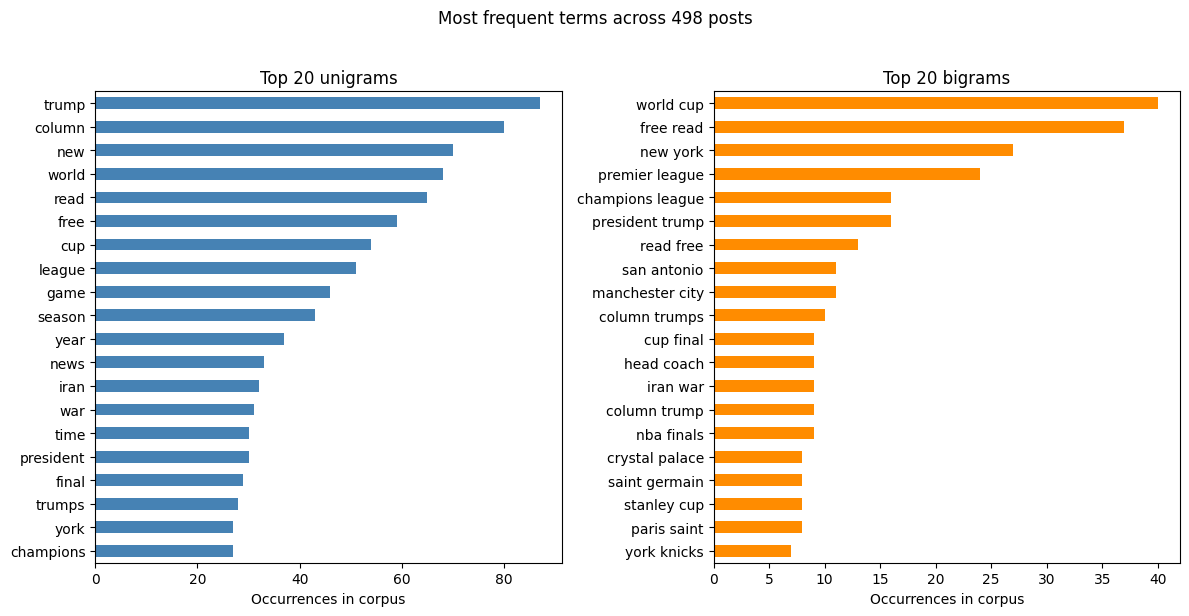

In [16]:
fig, (ax_uni, ax_bi) = plt.subplots(1, 2, figsize=(12, 6))

unigram_counts.head(20).iloc[::-1].plot.barh(ax=ax_uni, color='steelblue')
ax_uni.set_title('Top 20 unigrams')
ax_uni.set_xlabel('Occurrences in corpus')

bigram_counts.head(20).iloc[::-1].plot.barh(ax=ax_bi, color='darkorange')
ax_bi.set_title('Top 20 bigrams')
ax_bi.set_xlabel('Occurrences in corpus')

fig.suptitle(f'Most frequent terms across {len(corpus_df)} posts', y=1.02)
fig.tight_layout()

### 3.1 What makes each account distinctive?

Raw frequency tables describe the corpus as a whole, but our research design is comparative: a *panel* of accounts. Comparing each account's raw top words mostly re-discovers who posts the most. The standard fix is a **log-odds ratio**: for each word, take the *odds* that account A uses it (the word's count in A's posts relative to all of A's other words) and the same odds in everyone else's posts, and look at the logarithm of their ratio. Zero means "used at the same rate as everyone else"; large positive values mean distinctively *A's* vocabulary; the logarithm makes over- and under-use symmetric around zero. We use the smoothed version (add 0.5 to every count) from Monroe, Colaresi, & Quinn (2008), implemented as `textprep.log_odds`, and only score words an account used at least three times so rare flukes don't dominate.

In [17]:
# Word counts aggregated by account: one row per account, one column per word
account_word_counts = (
    pd.DataFrame(
        unigram_dtm.toarray(),
        index = corpus_df['author'].values,
        columns = unigram_vectorizer.get_feature_names_out(),
    )
    .groupby(level=0).sum()
)

distinctive = {}
for account in account_word_counts.index:
    own = account_word_counts.loc[account]
    rest = account_word_counts.drop(index=account).sum()
    scores = textprep.log_odds(own, rest)
    # Only consider words this account used at least 3 times
    scores = scores[own[scores.index] >= 3]
    distinctive[account] = scores.head(8).index.tolist()

pd.DataFrame.from_dict(distinctive, orient='index',
                       columns=[f'word_{i+1}' for i in range(8)])

,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8
nickkristof.bsky.social,good,ice,administration,agents,americans,states,epstein,study
nytimes.com,center,hall,israeli,NaN,NaN,NaN,NaN,NaN
nytopinion.nytimes.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
theathletic.com,knicks,nba,finals,spurs,san,antonio,stanley,brunson
theathleticfc.bsky.social,premier,arsenal,club,manchester,chelsea,liverpool,madrid,football
thomaslfriedman.bsky.social,nyt,word,opinions,button,planet,ukraine,save,mideast


Each row reads like a thumbnail sketch of an account's beat — and that is exactly the kind of *face validity check* Grimmer & Stewart prescribe: before trusting any statistic, look at whether the words it surfaces make sense for accounts you know.

## 4. Sentiment analysis with VADER

**Dictionary methods** score documents by looking words up in a curated lexicon. For social media the standard dictionary is **VADER** (Valence Aware Dictionary and sEntiment Reasoner; [Hutto & Gilbert 2014](https://doi.org/10.1609/icwsm.v8i1.14550); [code and lexicon on GitHub](https://github.com/cjhutto/vaderSentiment)), built *for* microblog text: its lexicon was rated by crowd workers on tweets and includes emoticons, slang, and acronyms, and its scoring rules use exactly the signals we stripped out in Section 2 — capitalization ("GREAT" beats "great"), exclamation points, intensifiers ("very"), contrastive "but," and simple negation ("not good").

That is why VADER gets the **raw text**, not `clean_text`. Preprocessing is method-specific: what is noise to a topic model is signal to VADER.

VADER's **compound score** is its single overall summary of a text: a normalized, weighted sum of the lexicon scores of every word it recognizes (after the rule-based adjustments), squashed onto a scale from -1 (most negative) to +1 (most positive). Values between -0.05 and +0.05 are conventionally read as neutral. Watch it respond to its designed-for signals — and fail on sarcasm:

In [18]:
analyzer = SentimentIntensityAnalyzer()

demos = [
    'The new feature is good.',
    'The new feature is GOOD!!!',          # capitalization and punctuation boost
    'The new feature is not good.',        # simple negation handled
    'The new feature is good :(',          # emoticons counted
    'Oh great, ANOTHER outage. Just what I needed today.',   # sarcasm: not handled
]

for sentence in demos:
    score = analyzer.polarity_scores(sentence)['compound']
    print(f"{score:+.3f}  {sentence}")

+0.440  The new feature is good.
+0.671  The new feature is GOOD!!!
-0.341  The new feature is not good.
+0.000  The new feature is good :(
+0.625  Oh great, ANOTHER outage. Just what I needed today.


The first four behave as designed. The last one is plainly sarcastic frustration, but "great" and "needed" read as positive to a word list — keep that failure in mind whenever you see an aggregate sentiment number.

Score every post in the corpus on its raw text:

In [19]:
corpus_df['sentiment'] = corpus_df['text'].map(
    lambda text: analyzer.polarity_scores(text)['compound']
)

corpus_df['sentiment'].describe()

count    498.000000
mean       0.131224
std        0.513616
min       -0.982900
25%       -0.202300
50%        0.000000
75%        0.585900
max        0.969400
Name: sentiment, dtype: float64

The summary statistics above compress the whole corpus into a handful of numbers; a histogram shows the *shape* of the distribution they hide. Before looking, predict one feature: VADER returns exactly 0 for any post containing no lexicon words at all, so short posts should produce a spike at zero.

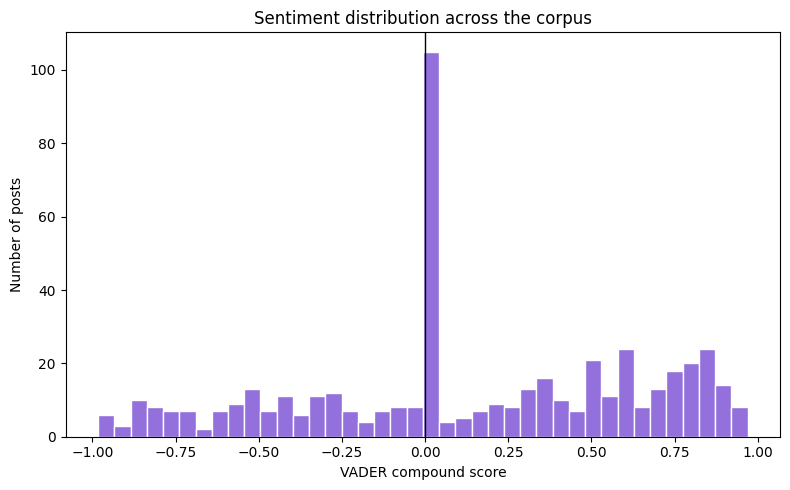

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(corpus_df['sentiment'], bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('VADER compound score')
ax.set_ylabel('Number of posts')
ax.set_title('Sentiment distribution across the corpus')

fig.tight_layout()

The big spike at exactly zero is typical of short text: many posts contain no lexicon words at all, so VADER returns neutral by default. "Neutral" here often means "no evidence," not "measured neutrality" — another reason to inspect examples.

Which we do next, but with an ethics rule from this series' conventions: we display verbatim posts **only from the seed account** (the author of these tutorials, who has opted in). For the other panel accounts we report aggregates and would paraphrase rather than quote if we needed examples — verbatim text is trivially re-identifiable via search.

In [21]:
seed_posts = corpus_df[corpus_df['author'] == SEED_ACCOUNT].sort_values('sentiment')

print('Most NEGATIVE posts from', SEED_ACCOUNT)
for _, row in seed_posts.head(3).iterrows():
    print(f"  {row['sentiment']:+.3f}  {row['text'][:120]!r}")

print('\nMost POSITIVE posts from', SEED_ACCOUNT)
for _, row in seed_posts.tail(3).iterrows():
    print(f"  {row['sentiment']:+.3f}  {row['text'][:120]!r}")

Most NEGATIVE posts from nytimes.com
  -0.863  'A driver of a car hit a protester at Delaney Hall, an immigration detention center in Newark that has been the site of p'
  -0.784  'A Palestinian infant was killed when Israeli forces opened fire on a car in which the boy and several relatives were tra'
  -0.527  'The Pentagon has raised its counterintelligence threat level for Israel amid concerns about eavesdropping on U.S.-Iran t'

Most POSITIVE posts from nytimes.com
  +0.586  'Hundreds of items from Diane Keaton’s estate will be up for auction this June, including her designer and vintage clothi'
  +0.768  'Hollywood is struggling, but Steven Spielberg insists that the big screen is still the best place to work out our collec'
  +0.904  "The details on Taylor Swift and Travis Kelce's wedding are scarce, but that doesn’t mean you can’t celebrate the event o"


Read those "most positive" posts carefully: depending on the run, you will likely find at least one that is biting sarcasm wearing positive vocabulary — words like "fun," "hope," or "LOL" deployed ironically. The extremes of a dictionary score are exactly where its failure modes concentrate, which is why inspecting them (rather than just plotting the distribution) belongs in your standard workflow. We return to this in Section 4.2 and Section 7.

### 4.1 Sentiment over time

O'Connor *et al.* (2010) aggregated tweet sentiment into time series and found it tracked national polls — the founding demonstration that cheap text measures can proxy expensive surveys. At our small scale we can do the descriptive version: resample posts to months with pandas' [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) and plot the mean compound score with a 95% confidence band (mean ± 1.96 standard errors), skipping months with too few posts to say anything.

With ~1,400 posts from seven accounts this is a *demonstration*, not an inference — the composition of who is posting shifts month to month, so swings can reflect *who* posted as much as *how things felt*. A research version would model account fixed effects or weight the panel.

,mean,sem,count
created_at,,,
2026-01-01 00:00:00+00:00,-0.008,0.081,49
2026-02-01 00:00:00+00:00,-0.107,0.095,39
2026-03-01 00:00:00+00:00,-0.123,0.112,28
2026-04-01 00:00:00+00:00,-0.102,0.101,23
2026-05-01 00:00:00+00:00,0.305,0.032,218
2026-06-01 00:00:00+00:00,0.049,0.054,71


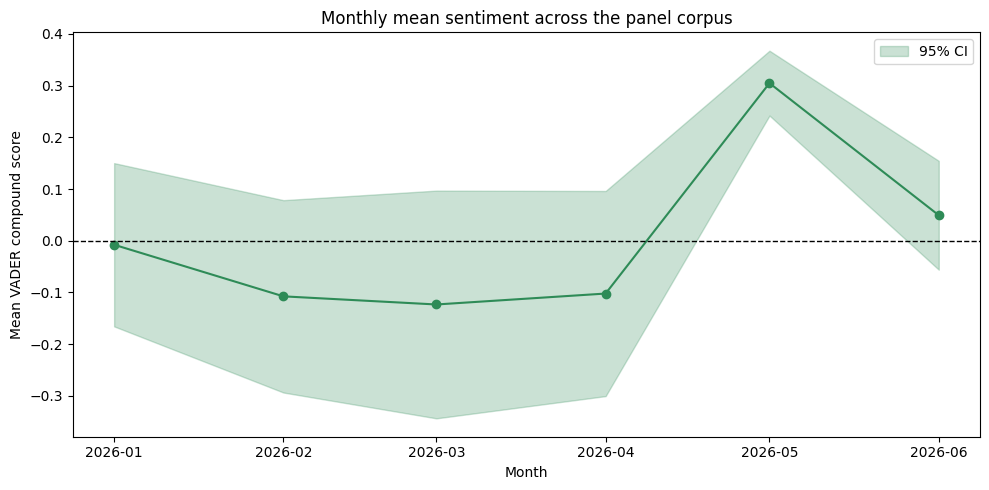

In [22]:
monthly = (
    corpus_df
    .set_index('created_at')
    .resample('MS')['sentiment']
    .agg(['mean', 'sem', 'count'])
)

# Only show months with a reasonable number of posts
monthly = monthly[monthly['count'] >= 20]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly.index, monthly['mean'], marker='o', color='seagreen')
ax.fill_between(
    monthly.index,
    monthly['mean'] - 1.96 * monthly['sem'],
    monthly['mean'] + 1.96 * monthly['sem'],
    alpha=0.25, color='seagreen', label='95% CI'
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Month')
ax.set_ylabel('Mean VADER compound score')
ax.set_title('Monthly mean sentiment across the panel corpus')
ax.legend()

fig.tight_layout()
monthly.round(3)

### 4.2 Where dictionaries break

VADER's documented strengths are real — on social media benchmarks it beat individual human raters at the time of publication — but every dictionary inherits three structural weaknesses:

* **Negation and scope.** VADER catches "not good" but longer-range or subtler negation ("I wish I could say this was good") slips through.
* **Sarcasm and irony.** As demonstrated above; communities with heavily ironic registers (very much a microblogging tradition) can invert the measure entirely.
* **Domain drift.** Lexicon ratings are frozen at collection time, on the platforms and slang of that moment. "Sick" as praise, community in-jokes, or political terms whose valence flips over time all decay a dictionary's validity. VADER was rated on early-2010s tweets; Bluesky in 2026 is a related but distinct dialect.

The remedy is not a better dictionary but a validation habit: hand-score a random sample yourself and check the agreement (Section 7), and treat sentiment trends as hypotheses to inspect, not findings to report.

## 5. Topic modeling with LDA

Where dictionaries impose categories, **unsupervised** methods discover them — they find structure in the data without being shown any labeled examples. **Latent Dirichlet Allocation (LDA)** ([Blei, Ng, & Jordan 2003](https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf)) models each document as a *mixture of topics* and each topic as a *distribution over words*, then asks: what topics and mixtures would best explain the word counts we observed? Note the technical meaning of **topic** here: nothing more than a probability distribution over the vocabulary. Whether a given distribution corresponds to a human-recognizable theme is an empirical question, not a guarantee. We fit the model with scikit-learn's [`LatentDirichletAllocation`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html). The output is wonderfully suited to social science questions — what does this panel talk about, and who talks about what? — as long as you remember the model knows nothing about meaning, only co-occurrence.

Two practical preprocessing tweaks for the topic model's document-term matrix:

* `min_df=5`: words in fewer than five posts can't support a topic.
* `max_df=0.4`: words in more than 40% of posts (corpus-wide filler) don't *distinguish* topics.

We fit `k=8` topics. Fair warning: LDA was designed for long documents, and 300-character posts are about the hardest case — short texts give the model very little co-occurrence evidence per document, so expect a couple of crisp topics and a couple of junk ones.

In [23]:
lda_vectorizer = CountVectorizer(
    token_pattern = r'\S+',
    lowercase = False,
    min_df = 5,      # word must appear in at least 5 posts
    max_df = 0.4,    # ...and fewer than 40% of posts
)
lda_dtm = lda_vectorizer.fit_transform(corpus_df['clean_text'])

N_TOPICS = 8
lda_model = LatentDirichletAllocation(
    n_components = N_TOPICS,
    learning_method = 'batch',
    max_iter = 25,
    random_state = 42,    # LDA is stochastic: fix the seed for reproducibility
)

# Rows of doc_topic_shares are each post's mixture over the 8 topics
doc_topic_shares = lda_model.fit_transform(lda_dtm)

print(f"Modeled {lda_dtm.shape[0]} posts over a {lda_dtm.shape[1]}-word vocabulary "
      f"with {N_TOPICS} topics")

Modeled 498 posts over a 297-word vocabulary with 8 topics


### 5.1 Reading the topics

A fitted LDA is interpreted through its top words: for each topic, the words with the highest weight in that topic's distribution. `textprep.top_topic_words` tabulates the top 12. Read each row and try to name the topic — if you can't, that's diagnostic data, not a personal failing.

In [24]:
topic_words = textprep.top_topic_words(
    lda_model,
    lda_vectorizer.get_feature_names_out(),
    n_words = 12,
)
topic_words

,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10,word_11,word_12
topic_0,news,team,season,best,home,player,championship,lead,year,game,right,football
topic_1,read,free,game,spurs,united,finals,year,san,antonio,nba,monday,did
topic_2,read,free,big,news,details,playing,israeli,new,life,assists,state,immigration
topic_3,season,read,free,league,year,coach,head,champions,real,story,new,work
topic_4,world,cup,squad,players,mauricio,fifa,summer,years,roster,soccer,man,venezuela
topic_5,trump,column,iran,war,president,trumps,new,good,america,administration,alex,ice
topic_6,new,league,york,city,arsenal,champions,premier,american,israel,manchester,final,years
topic_7,game,win,time,final,cup,million,knicks,goal,stanley,raised,giving,guide


### 5.2 Documents as topic mixtures

Each post gets a vector of topic shares summing to 1. Here is the corpus' single most topic-concentrated post from the seed account, with its mixture — most short posts are dominated by one or two topics, with the rest of the mass spread thinly (an artifact of the Dirichlet prior as much as of the writing).

In [25]:
seed_mask = (corpus_df['author'] == SEED_ACCOUNT).values
seed_shares = doc_topic_shares[seed_mask]

# The seed post whose mixture is most concentrated on a single topic
most_concentrated = seed_shares.max(axis=1).argmax()
example_post = corpus_df[seed_mask].iloc[most_concentrated]

print(f"Post: {example_post['text'][:200]!r}\n")
print('Topic shares:')
for topic_idx, share in enumerate(seed_shares[most_concentrated]):
    bar = '#' * int(share * 40)
    print(f"  topic_{topic_idx}  {share:.2f}  {bar}")

Post: 'Federal officials will allow visitors back inside the Delaney Hall immigration detention center in Newark, Gov. Mikie Sherrill of New Jersey said on Sunday, after a second straight night of clashes be'

Topic shares:
  topic_0  0.01  
  topic_1  0.01  
  topic_2  0.91  ####################################
  topic_3  0.01  
  topic_4  0.01  
  topic_5  0.01  
  topic_6  0.01  
  topic_7  0.01  


### 5.3 Topic prevalence by account

Averaging topic shares within each account gives a *topic profile* — the unsupervised cousin of Section 3's distinctive-words table. A heatmap makes the panel's division of attention legible at a glance: read a row to see what an account talks about, a column to see who owns a topic.

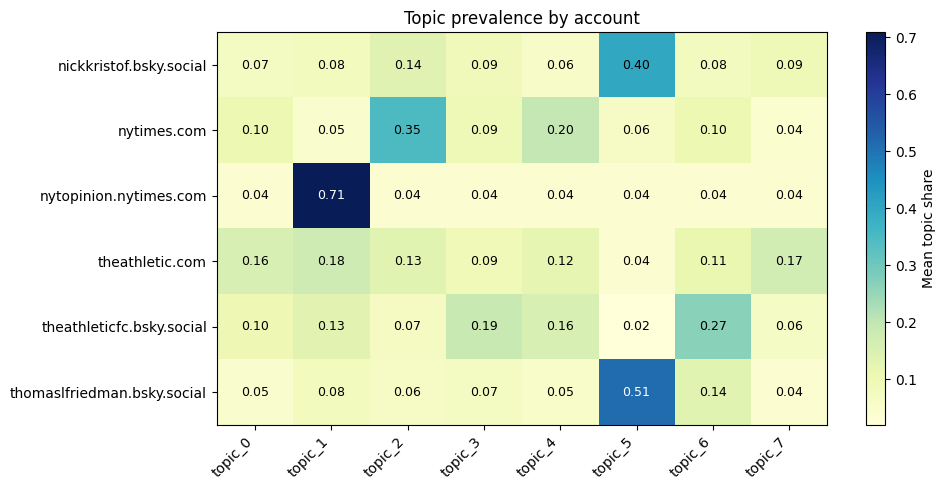

In [26]:
topic_by_account = (
    pd.DataFrame(
        doc_topic_shares,
        index = corpus_df['author'].values,
        columns = [f'topic_{i}' for i in range(N_TOPICS)],
    )
    .groupby(level=0).mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

image = ax.imshow(topic_by_account.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(N_TOPICS), topic_by_account.columns, rotation=45, ha='right')
ax.set_yticks(range(len(topic_by_account)), topic_by_account.index)

# Annotate each cell with its share
for i in range(topic_by_account.shape[0]):
    for j in range(topic_by_account.shape[1]):
        value = topic_by_account.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                color='white' if value > 0.4 else 'black', fontsize=9)

fig.colorbar(image, ax=ax, label='Mean topic share')
ax.set_title('Topic prevalence by account')

fig.tight_layout()

### 5.4 Choosing k, and other confessions

We set `k=8` because it produced readable topics for a corpus of this size — which is to say, we chose it the way most people actually do. Honest caveats:

* **There is no true k.** Held-out **perplexity** — a score measuring how surprised the fitted model is by documents it never saw during training (lower = better fit; scikit-learn exposes it as [`LatentDirichletAllocation.perplexity`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html#sklearn.decomposition.LatentDirichletAllocation.perplexity)) — can guide the choice, but Chang *et al.* (2009) showed perplexity can *anti*-correlate with human topic interpretability. Fit several values, read the topics, and report the sensitivity.
* **Topics are not concepts.** They are co-occurrence clusters. Two themes that share vocabulary merge; one theme discussed in two registers splits. Naming topics is an interpretive act you should document (and ideally have a second coder replicate).
* **Instability.** Different random seeds yield different topics; we fixed `random_state` for reproducibility, which makes the *notebook* stable, not the *finding*.
* **Short texts strain LDA.** Common upgrades: pool posts by author or by week into pseudo-documents, use biterm topic models, or move to embeddings (next section).

The Grimmer & Stewart rule applies with full force: an LDA topic enters a paper only after validation — top words, top *documents*, and a human check that the label fits.

## 6. Beyond word counts: transformer sentence embeddings

Everything above treated documents as bags of words, discarding order, syntax, and context. The modern alternative is to encode each post as a dense vector — a **sentence embedding** — using a pretrained transformer model (Reimers & Gurevych 2019). Posts that *mean* similar things land near each other in vector space even when they share no vocabulary ("the eagles won" / "philadelphia takes the championship"), which dissolves much of Section 2: no stopword lists, no stemming debates, decent multilingual coverage from multilingual models.

Embeddings power the modern versions of everything in this notebook — clustering posts into topics (e.g., BERTopic), semantic search over a corpus, and features for supervised classifiers — and Part 07 uses the image-text version (CLIP) on visual content. The pattern is three lines; the cell below runs if you have `sentence-transformers` installed and explains itself if you don't:

In [27]:
example_posts = corpus_df['text'].head(3).tolist()

try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('all-MiniLM-L6-v2')   # small, fast, solid baseline
    embeddings = model.encode(example_posts)
    print(f"Encoded {len(example_posts)} posts into vectors of dimension {embeddings.shape[1]}")
except ImportError:
    print('sentence-transformers is not installed, so this stub did not run.')
    print('Install it (pip install sentence-transformers) to embed posts in three lines.')

sentence-transformers is not installed, so this stub did not run.
Install it (pip install sentence-transformers) to embed posts in three lines.


The trade-off is interpretability: a topic's top words can be printed and argued about; the 384 dimensions of an embedding cannot. For research that must justify its measures, count-based methods plus validation remain a defensible — sometimes preferable — choice.

## 7. Validate, validate, validate

Grimmer & Stewart (2013) close their review of text-as-data methods with a three-word command — **"validate, validate, validate"** — because every method in this notebook produces numbers whether or not those numbers mean anything. The cheapest, highest-value validation is also the least glamorous: **read a random sample and check**.

The cell below draws a reproducible random sample of seed-account posts and lays the automated measures alongside the text. Read each one and ask: does the sentiment score match your reading? Does the dominant topic's label fit? Tally your agreement rate — for a real project you would do this with a few hundred posts, multiple coders, and a chance-corrected agreement statistic like Cohen's kappa.

In [28]:
dominant_topic = doc_topic_shares.argmax(axis=1)

validation_sample = (
    corpus_df
    .assign(dominant_topic=dominant_topic)
    .loc[lambda d: d['author'] == SEED_ACCOUNT]
    .sample(n=8, random_state=42)     # seeded so the sample is reproducible
)

for _, row in validation_sample.iterrows():
    top_words = ', '.join(topic_words.loc[f"topic_{row['dominant_topic']}"].head(4))
    print(f"sentiment {row['sentiment']:+.2f} | topic_{row['dominant_topic']} ({top_words})")
    print(f"   {row['text'][:160]!r}\n")

sentiment -0.15 | topic_2 (read, free, big, news)
   'Federal officials will allow visitors back inside the Delaney Hall immigration detention center in Newark, Gov. Mikie Sherrill of New Jersey said on Sunday, aft'

sentiment +0.59 | topic_4 (world, cup, squad, players)
   'Hundreds of items from Diane Keaton’s estate will be up for auction this June, including her designer and vintage clothing, her art collection and mementos, lik'

sentiment +0.90 | topic_2 (read, free, big, news)
   "The details on Taylor Swift and Travis Kelce's wedding are scarce, but that doesn’t mean you can’t celebrate the event of the season. Try our fantasy wedding pl"

sentiment -0.36 | topic_4 (world, cup, squad, players)
   'Browsing LinkedIn today can turn up the kind of videos, sponsored content and memes reminiscent of other social media platforms. Has all this expanded its appea'

sentiment -0.53 | topic_6 (new, league, york, city)
   'The Pentagon has raised its counterintelligence threat level for I

You will probably find a few clear mismatches — a sarcastic post scored positive, a post assigned to a topic by one incidental word. That experience, not any summary statistic, is what calibrates how much weight your measures can bear.

Hand-coding is the bottleneck of content analysis, which is why **Part 08** picks up exactly here: using a large language model as an annotator at scale, and — because an LLM is just another instrument — validating *it* against a hand-coded gold sample with formal agreement metrics. The validation habit transfers unchanged; only the instrument gets fancier.

## 8. Saving the corpus and results

Following the series' reproducibility convention, we save the analysis-ready corpus (with sentiment scores) to Parquet, the topic table to CSV, and a small JSON of collection parameters and dates alongside them — so the analyses above can be re-run from disk without touching the API, and so future-you knows exactly what this archive is.

In [29]:
import json
from pathlib import Path

Path('data').mkdir(exist_ok=True)

# The analysis-ready corpus: one row per post
corpus_df[['uri', 'author', 'created_at', 'text', 'sentiment']].to_parquet(
    'data/corpus.parquet', index=False
)

# The fitted topic model's top words
topic_words.to_csv('data/topic_top_words.csv')

# Collection parameters, for reproducibility
metadata = {
    'collected_on': COLLECTED_ON,
    'seed_account': SEED_ACCOUNT,
    'panel_accounts': panel_handles,
    'max_seed_posts': 600,
    'max_panel_posts_each': 150,
    'language_filter': 'en',
    'n_posts_saved': len(corpus_df),
    'lda_topics': N_TOPICS,
    'lda_random_state': 42,
}
with open('data/collection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

for path in sorted(Path('data').iterdir()):
    print(f"{path}  ({path.stat().st_size:,} bytes)")

data/collection_metadata.json  (397 bytes)
data/corpus.parquet  (83,004 bytes)
data/topic_top_words.csv  (761 bytes)


And the reload check — any later session (or any later Part) can pick up the corpus from here:

In [30]:
reloaded = pd.read_parquet('data/corpus.parquet')

print(f"Reloaded {len(reloaded)} posts from data/corpus.parquet")
reloaded.head(3)

Reloaded 498 posts from data/corpus.parquet


,uri,author,created_at,text,sentiment
0,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnufj522tk2v,nytimes.com,2026-06-09 14:23:16.191000+00:00,"The details on Taylor Swift and Travis Kelce's wedding are scarce, but that doesn’t mean you can...",0.9042
1,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnqarb4ons2u,nytimes.com,2026-06-07 22:47:41.229000+00:00,"Hollywood is struggling, but Steven Spielberg insists that the big screen is still the best plac...",0.7684
2,at://did:plc:eclio37ymobqex2ncko63h4r/app.bsky.feed.post/3mnpqno56p22y,nytimes.com,2026-06-07 17:59:20.803000+00:00,Breaking News from @theathletic.com: Alexander Zverev defeated Flavio Cobolli in a dramatic five...,-0.4019


## Ethics and limitations

**Public text is still people's speech.** Most Bluesky users have not read the protocol docs and may not expect their posts in a research corpus (Fiesler & Proferes 2018). This notebook's conventions are deliberate: the verbatim examples come only from the seed account (a national newsroom whose posts are professional output); for everyone else we report aggregates — frequency tables, topic shares, monthly means — and would paraphrase rather than quote, because verbatim posts are trivially re-identifiable via search (Zimmer 2010). The saved corpus records its collection date so deletions can be honored if the archive is ever shared; better still, share derived measures rather than raw text.

**A mention-based panel is not a sample.** Seven accounts in one newsroom's conversational orbit — mostly its own sister accounts and journalists — support a tutorial, not a population claim. Bluesky's user base itself skews toward early adopters and Twitter migrants, so even a good sample of it would not generalize to "the public."

**The English filter has politics.** Filtering on self-declared `langs` both mislabels posts and excludes non-English speakers from the analysis entirely. A multilingual research design needs multilingual tools (and the embeddings of Section 6 are a start).

**Measures are not meanings.** VADER misses sarcasm and drifts across domains; LDA topics are co-occurrence clusters that merge, split, and shift with the random seed; word counts ignore order and context. Every number above is a model output, defensible only to the extent it has been validated against human reading — which is also the bridge to Part 08.

**Behavior under incentives, not attitudes.** Posts measure public expression on a platform, with its norms and audiences — not private belief. A panel's sentiment trend tells you how they *post*, not how they *feel*.

## Exercises

Each exercise extends this notebook. The first few are small modifications; the later ones are mini-analyses you could write up in a page or two.

1. **Change the number of topics.** Re-fit the Section 5 model with `N_TOPICS = 5` and again with `N_TOPICS = 12`, regenerating the top-words table each time. Which of the `k=8` topics merge at 5, and which split at 12? Write one sentence per model saying which value you would defend and why — recall from Section 5.4 that there is no true *k*, only a documented choice.

2. **Add custom stopwords.** Look at the top-20 unigram chart in Section 3 and pick two or three words that read as corpus-specific filler rather than content. Add them to the stopword set (extend `CUSTOM_STOPWORDS` in `textprep.py`, or build `extra = textprep.STOPWORDS | {'wordA', 'wordB'}` and filter in your own preprocessing call), then re-run Sections 3 and 5. How sensitive are the frequency rankings and topics to this small change?

3. **Swap the panel.** Re-run Section 1 with `SEED_ACCOUNT = 'bsky.app'` (the official Bluesky account) and let the mention snowball build a new panel. Compare the distinctive-words table and topic heatmap to the originals. What does the contrast teach you about how much these measures depend on corpus construction rather than on the method?

4. **Bigram topics.** The LDA vectorizer in Section 5 uses unigrams only. Add `ngram_range=(1, 2)` and refit. Are the top-words tables easier or harder to label? Watch what happens to the vocabulary size printed by the fitting cell, and think about why a much larger vocabulary might hurt a model with only ~1,400 very short documents.

5. **Sentiment around an event.** Find a month where the Section 4.1 trend line dips or spikes. Filter `corpus_df` to that month, sort by `sentiment`, and read the ten most extreme posts (respecting the quoting convention: verbatim only for the seed account, paraphrase for others). Was the swing driven by a real-world event, by a change in *who* was posting, or by a VADER failure mode? Deliver a 3–4 sentence verdict with evidence.

6. **Distinctive terms, head to head.** Adapt Section 3.1 to compare just two panel accounts directly: build their word-count rows and compute `textprep.log_odds(counts_A, counts_B)`, then inspect *both* tails — the largest values are distinctively A's vocabulary, the smallest distinctively B's. This two-corpus design is exactly the "fightin' words" setting of Monroe, Colaresi, & Quinn (2008).

## Research project ideas

**1. How do newsrooms frame the same story differently?** *Question:* when several news organizations on Bluesky cover the same event, do they use systematically different vocabularies and emphases? *Data:* a panel corpus built with Section 1's collector, but with a defensible, criterion-based panel — say, 10–20 newsroom accounts chosen *before* looking at their content — restricted to a pre-registered window around one event. *Method:* distinctive-terms log-odds between outlets (Section 3.1) plus an LDA fitted on the pooled corpus with topic prevalence by outlet (Section 5.3); have two coders independently label the topics and a sample of posts, and report a chance-corrected agreement statistic, following Grimmer & Stewart's (2013) validation injunction and standard content-analysis practice (Krippendorff 2018). *Expected challenge:* 300-character posts give LDA very thin co-occurrence evidence, so you will likely need to pool posts into per-outlet-per-day pseudo-documents — a preprocessing decision that itself requires justification and a sensitivity check.

**2. An audit of off-the-shelf sentiment on Bluesky.** *Question:* how valid is VADER on 2026 Bluesky text, and where exactly does it fail? Van Atteveldt, van der Velden, & Boukes (2021) ran this design on Dutch news headlines and found dictionary methods trailing far behind both human coders and trained classifiers — does the same hold here? *Data:* a few thousand posts from a topical corpus (the Part 02 authenticated-search workflow), with a random sample of ~300 posts hand-coded negative/neutral/positive by two or three coders. *Method:* threshold VADER's compound score into the same three classes and compare against the human gold standard — overall accuracy, per-class recall, and a qualitative autopsy of the misses (sarcasm? emoji? community slang the 2014 lexicon never saw?). *Expected challenge:* the bottleneck is the codebook — if your human coders cannot agree with each other (low Krippendorff's alpha), no instrument can be meaningfully validated against their labels. This design connects directly to Part 08, where an LLM joins the comparison as a third instrument.

**3. Do network communities talk differently?** *Question:* do the follow-graph communities detected in Part 03 have measurably distinctive vocabularies — that is, do structural and linguistic boundaries coincide? *Data:* community assignments from a Part 03 collection, plus author-feed corpora (this notebook's collector) for the accounts in the two or three largest communities. *Method:* distinctive-terms analysis and topic prevalence by community, then a simple bag-of-words classifier predicting community membership from `clean_text`; validate by reading the highest- and lowest-confidence predictions and identifying *which* words carry the signal. *Expected challenge:* communities differ in many correlated ways at once — topic, register, geography, demographics — so the interesting work is disentangling *why* the text is classifiable, not just reporting that it is; without that interpretive validation step the accuracy number invites overclaiming.

## References

### Scholarship

* Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). [Latent Dirichlet Allocation](https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf). *Journal of Machine Learning Research*, 3, 993–1022.
* Chang, J., Boyd-Graber, J., Gerrish, S., Wang, C., & Blei, D. M. (2009). [Reading tea leaves: How humans interpret topic models](https://papers.nips.cc/paper/3700-reading-tea-leaves-how-humans-interpret-topic-models). *NeurIPS*.
* Fiesler, C., & Proferes, N. (2018). ["Participant" perceptions of Twitter research ethics](https://doi.org/10.1177/2056305118763366). *Social Media + Society*, 4(1).
* Grimmer, J., & Stewart, B. M. (2013). [Text as data: The promise and pitfalls of automatic content analysis methods for political texts](https://doi.org/10.1093/pan/mps028). *Political Analysis*, 21(3), 267–297.
* Hutto, C. J., & Gilbert, E. (2014). [VADER: A parsimonious rule-based model for sentiment analysis of social media text](https://doi.org/10.1609/icwsm.v8i1.14550). *ICWSM*.
* Monroe, B. L., Colaresi, M. P., & Quinn, K. M. (2008). [Fightin' words: Lexical feature selection and evaluation for identifying the content of political conflict](https://doi.org/10.1093/pan/mpn018). *Political Analysis*, 16(4), 372–403.
* O'Connor, B., Balasubramanyan, R., Routledge, B. R., & Smith, N. A. (2010). [From tweets to polls: Linking text sentiment to public opinion time series](https://doi.org/10.1609/icwsm.v4i1.14031). *ICWSM*.
* Reimers, N., & Gurevych, I. (2019). [Sentence-BERT: Sentence embeddings using Siamese BERT-networks](https://doi.org/10.18653/v1/D19-1410). *EMNLP*.
* Zimmer, M. (2010). ["But the data is already public": On the ethics of research in Facebook](https://doi.org/10.1007/s10676-010-9227-5). *Ethics and Information Technology*, 12(4), 313–325.
* Grimmer, J., Roberts, M. E., & Stewart, B. M. (2022). [*Text as Data: A New Framework for Machine Learning and the Social Sciences*](https://press.princeton.edu/books/paperback/9780691207551/text-as-data). Princeton University Press.
* Krippendorff, K. (2018). [*Content Analysis: An Introduction to Its Methodology*](https://doi.org/10.4135/9781071878781) (4th ed.). SAGE.
* van Atteveldt, W., van der Velden, M. A. C. G., & Boukes, M. (2021). [The validity of sentiment analysis: Comparing manual annotation, crowd-coding, dictionary approaches, and machine learning algorithms](https://doi.org/10.1080/19312458.2020.1869198). *Communication Methods and Measures*, 15(2), 121–140.

### Documentation

* Bluesky HTTP API reference: [docs.bsky.app](https://docs.bsky.app) — [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), [`app.bsky.feed.searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts), [`app.bsky.actor.getProfiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles)
* scikit-learn: [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [`LatentDirichletAllocation`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html), and the [text feature extraction guide](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
* pandas: [user guide](https://pandas.pydata.org/docs/user_guide/index.html), [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html), [`read_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html)
* VADER: [github.com/cjhutto/vaderSentiment](https://github.com/cjhutto/vaderSentiment)